# Task 1: Intelligent Reorder Recommendation System
**Bristol Regional Food Network Digital Marketplace**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, roc_auc_score,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print("All imports OK")


All imports OK


## 1. Synthetic Dataset Generation
Only fruits and vegetables are included, per the case study specification.

In [39]:
products = {
    "Fruit":     ["Apple", "Banana", "Orange", "Grapes", "Mango", "Strawberry"],
    "Vegetable": ["Tomato", "Potato", "Carrot", "Cucumber", "Onion", "Spinach", "Broccoli"]
}

all_products = [(p, cat) for cat, lst in products.items() for p in lst]

users = list(range(1, 31))  # 30 users for more signal

# Wider date range: 12 months enables seasonal features
date_range = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

# User preferences (each user has 4 favourite products)
user_preferences = {
    uid: np.random.choice([p for p, _ in all_products], size=4, replace=False)
    for uid in users
}

data = []
for user_id in users:
    num_purchases = np.random.randint(15, 35)
    for _ in range(num_purchases):
        if np.random.rand() < 0.70:
            product_name = np.random.choice(user_preferences[user_id])
        else:
            product_name = np.random.choice([p for p, _ in all_products])
        category = next(cat for p, cat in all_products if p == product_name)
        order_date = np.random.choice(date_range)
        quantity = np.random.randint(1, 6)
        data.append([user_id, product_name, category, pd.Timestamp(order_date), quantity])

df = pd.DataFrame(data, columns=["user_id","product_name","category","order_date","quantity"])
df = df.sort_values(["user_id","order_date"]).reset_index(drop=True)
df.to_csv("task1_synthetic_orders.csv", index=False)

print(f"Dataset shape: {df.shape}")
print(f"Users: {df['user_id'].nunique()}")
print(f"Products: {df['product_name'].nunique()} — {sorted(df['product_name'].unique())}")
print(f"Categories: {df['category'].unique()}")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print("\nSample rows:")
df.head(10)


Dataset shape: (753, 5)
Users: 30
Products: 13 — [np.str_('Apple'), np.str_('Banana'), np.str_('Broccoli'), np.str_('Carrot'), np.str_('Cucumber'), np.str_('Grapes'), np.str_('Mango'), np.str_('Onion'), np.str_('Orange'), np.str_('Potato'), np.str_('Spinach'), np.str_('Strawberry'), np.str_('Tomato')]
Categories: ['Vegetable' 'Fruit']
Date range: 2025-01-01 to 2025-12-31

Sample rows:


,user_id,product_name,category,order_date,quantity
0,1,Carrot,Vegetable,2025-01-05,4
1,1,Spinach,Vegetable,2025-02-27,2
2,1,Orange,Fruit,2025-04-02,2
3,1,Cucumber,Vegetable,2025-04-06,1
4,1,Potato,Vegetable,2025-04-24,2
5,1,Carrot,Vegetable,2025-04-26,5
6,1,Spinach,Vegetable,2025-04-27,1
7,1,Carrot,Vegetable,2025-05-22,4
8,1,Carrot,Vegetable,2025-05-24,5
9,1,Cucumber,Vegetable,2025-06-07,3


## 2. Exploratory Data Analysis

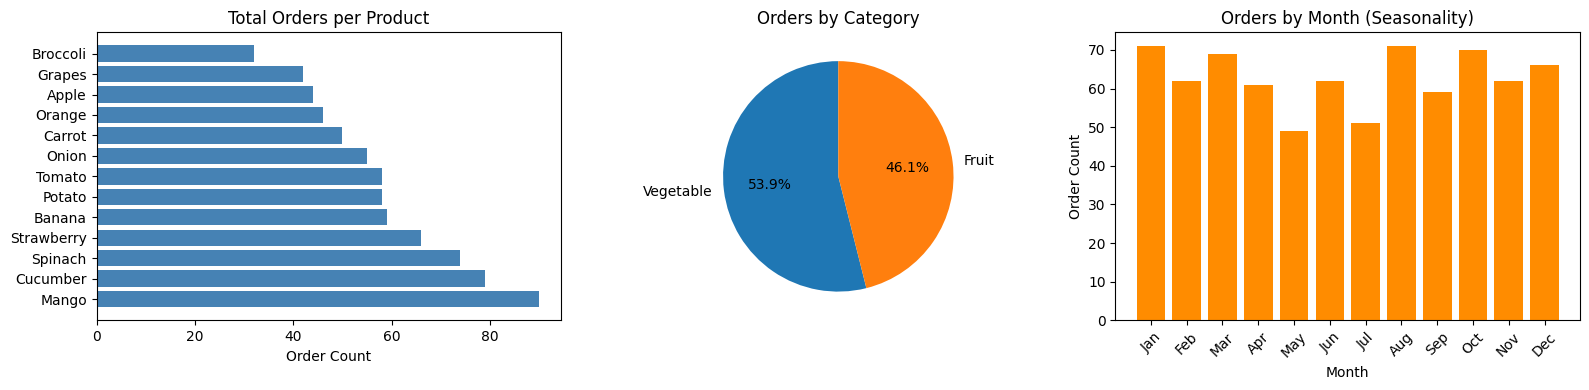

EDA charts saved.


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Orders per product
product_counts = df["product_name"].value_counts()
axes[0].barh(product_counts.index, product_counts.values, color="steelblue")
axes[0].set_title("Total Orders per Product")
axes[0].set_xlabel("Order Count")

# Orders by category
cat_counts = df["category"].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Orders by Category")

# Orders by month (seasonality)
df["month"] = df["order_date"].dt.month
monthly = df.groupby("month").size()
axes[2].bar(monthly.index, monthly.values, color="darkorange")
axes[2].set_title("Orders by Month (Seasonality)")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Order Count")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA charts saved.")


## 3. Baseline Recommender (Weighted RFM Scoring)
A rule-based baseline using Recency, Frequency and Monetary (quantity) scores. This gives us a performance floor to beat with ML.

In [41]:
def min_max_norm(series):
    mn, mx = series.min(), series.max()
    if mn == mx:
        return pd.Series([1.0]*len(series), index=series.index)
    return (series - mn) / (mx - mn)

reference_date = df["order_date"].max()

rfm = (
    df.groupby(["user_id","product_name","category"])
    .agg(frequency=("product_name","count"),
         total_quantity=("quantity","sum"),
         last_purchase_date=("order_date","max"))
    .reset_index()
)
rfm["days_since_last_purchase"] = (reference_date - rfm["last_purchase_date"]).dt.days
rfm["recency_raw"] = 1 / (rfm["days_since_last_purchase"] + 1)

rfm["freq_score"]     = rfm.groupby("user_id")["frequency"].transform(min_max_norm)
rfm["qty_score"]      = rfm.groupby("user_id")["total_quantity"].transform(min_max_norm)
rfm["recency_score"]  = rfm.groupby("user_id")["recency_raw"].transform(min_max_norm)

rfm["final_score"] = (0.5 * rfm["freq_score"]
                    + 0.3 * rfm["recency_score"]
                    + 0.2 * rfm["qty_score"])

def get_baseline_recommendations(user_id, top_n=3):
    recs = rfm[rfm["user_id"]==user_id].sort_values("final_score", ascending=False).head(top_n)
    for _, row in recs.iterrows():
        print(f"  {row['product_name']} ({row['category']}) — score: {row['final_score']:.3f} | "
              f"bought {row['frequency']}x | last {row['days_since_last_purchase']} days ago")

print("Baseline recommendations for User 1:")
get_baseline_recommendations(1)
print("\nBaseline recommendations for User 5:")
get_baseline_recommendations(5)


Baseline recommendations for User 1:
  Cucumber (Vegetable) — score: 0.940 | bought 7x | last 10 days ago
  Spinach (Vegetable) — score: 0.841 | bought 6x | last 11 days ago
  Carrot (Vegetable) — score: 0.538 | bought 5x | last 192 days ago

Baseline recommendations for User 5:
  Tomato (Vegetable) — score: 1.000 | bought 6x | last 25 days ago
  Strawberry (Fruit) — score: 0.864 | bought 6x | last 30 days ago
  Orange (Fruit) — score: 0.263 | bought 2x | last 62 days ago


## 4. Feature Engineering for ML
We frame reorder prediction as a binary classification: given a user-product pair in the purchase history, will they buy it again?

In [42]:
df["order_date"] = pd.to_datetime(df["order_date"])

# Temporal split: train on first 70% of timeline, test on last 30%
split_date = df["order_date"].quantile(0.7)
history_df = df[df["order_date"] <= split_date]
future_df  = df[df["order_date"] > split_date]

print(f"Split date: {split_date.date()}")
print(f"History rows: {len(history_df)}, Future rows: {len(future_df)}")

ref_date = history_df["order_date"].max()

features = (
    history_df.groupby(["user_id","product_name","category"])
    .agg(frequency=("product_name","count"),
         total_quantity=("quantity","sum"),
         avg_quantity=("quantity","mean"),
         last_purchase_date=("order_date","max"))
    .reset_index()
)

features["days_since_last_purchase"] = (ref_date - features["last_purchase_date"]).dt.days

# Seasonal feature: month of last purchase
features["last_purchase_month"] = features["last_purchase_date"].dt.month

future_pairs = set(zip(future_df["user_id"], future_df["product_name"]))
features["will_reorder"] = features.apply(
    lambda r: 1 if (r["user_id"], r["product_name"]) in future_pairs else 0, axis=1
)

enc = LabelEncoder()
features["category_encoded"] = enc.fit_transform(features["category"])

print(f"\nFeature set shape: {features.shape}")
print(f"Reorder rate: {features['will_reorder'].mean():.1%}  (class balance)")
features.head()


Split date: 2025-09-20
History rows: 527, Future rows: 226

Feature set shape: (204, 11)
Reorder rate: 48.5%  (class balance)


,user_id,product_name,category,frequency,total_quantity,avg_quantity,last_purchase_date,days_since_last_purchase,last_purchase_month,will_reorder,category_encoded
0,1,Apple,Fruit,2,8,4.0,2025-07-09,73,7,1,0
1,1,Carrot,Vegetable,5,22,4.4,2025-06-22,90,6,0,1
2,1,Cucumber,Vegetable,3,9,3.0,2025-06-25,87,6,1,1
3,1,Orange,Fruit,2,7,3.5,2025-08-21,30,8,0,0
4,1,Potato,Vegetable,1,2,2.0,2025-04-24,149,4,0,1


## 5. Model Comparison with Cross-Validation
We compare four algorithms using 5-fold stratified cross-validation to critically appraise competing approaches.

In [43]:
FEATURE_COLS = ["frequency","total_quantity","avg_quantity",
                "days_since_last_purchase","last_purchase_month","category_encoded"]

X = features[FEATURE_COLS]
y = features["will_reorder"]

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=500),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=5,
                                                   class_weight="balanced", random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    acc  = cross_val_score(model, X, y, cv=cv, scoring="accuracy").mean()
    f1   = cross_val_score(model, X, y, cv=cv, scoring="f1").mean()
    prec = cross_val_score(model, X, y, cv=cv, scoring="precision").mean()
    rec  = cross_val_score(model, X, y, cv=cv, scoring="recall").mean()
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"{name:25s}  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")

results_df = pd.DataFrame(results).T.round(3)
print("\nSummary table:")
print(results_df.to_string())


Logistic Regression        Acc=0.711  Prec=0.714  Rec=0.676  F1=0.689
Decision Tree              Acc=0.687  Prec=0.650  Rec=0.768  F1=0.703
Random Forest              Acc=0.726  Prec=0.689  Rec=0.788  F1=0.734
Gradient Boosting          Acc=0.682  Prec=0.662  Rec=0.707  F1=0.681

Summary table:
                     Accuracy  Precision  Recall     F1
Logistic Regression     0.711      0.714   0.676  0.689
Decision Tree           0.687      0.650   0.768  0.703
Random Forest           0.726      0.689   0.788  0.734
Gradient Boosting       0.682      0.662   0.707  0.681


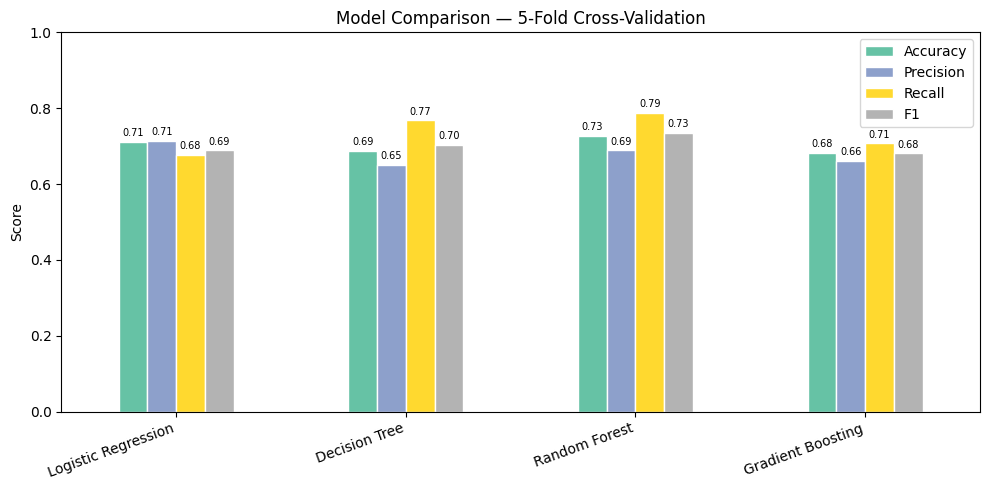

In [44]:
# Visualise the comparison
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("Model Comparison — 5-Fold Cross-Validation")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
ax.set_xticklabels(results_df.index, rotation=20, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Best Model, Random Forest: Detailed Evaluation & XAI

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y if y.nunique()>1 else None
)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest - Hold-Out Test Set")
print("-" * 40)
print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")


Random Forest - Hold-Out Test Set
----------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.62      0.73        32
           1       0.69      0.90      0.78        30

    accuracy                           0.76        62
   macro avg       0.78      0.76      0.75        62
weighted avg       0.78      0.76      0.75        62

ROC-AUC: 0.817


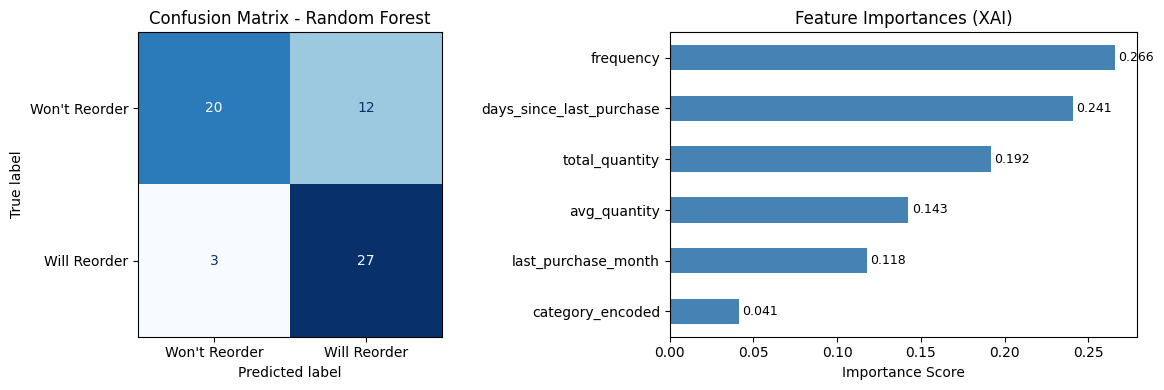

The feature importance chart shows WHICH signals the model uses to make recommendations,
giving transparency to end-users and producers.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
                                        display_labels=["Won't Reorder","Will Reorder"],
                                        colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix - Random Forest")

# Feature importance (XAI)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature Importances (XAI)")
axes[1].set_xlabel("Importance Score")
for i, v in enumerate(importances):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("rf_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()
print("The feature importance chart shows WHICH signals the model uses to make recommendations,")
print("giving transparency to end-users and producers.")


## 7. ML-Based Recommendations with Explanations

In [47]:
# Retrain on full dataset (not just train split) for final recommendations
rf_final = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)
rf_final.fit(X, y)

features["reorder_probability"] = rf_final.predict_proba(X)[:, 1]

def get_ml_recommendations(user_id, top_n=3):
    user_recs = (features[features["user_id"]==user_id]
                 .sort_values("reorder_probability", ascending=False)
                 .head(top_n))
    print(f"ML Reorder Recommendations for User {user_id}:\n")
    for _, row in user_recs.iterrows():
        print(f"  {row['product_name']} ({row['category']})")
        print(f"    Reorder probability : {row['reorder_probability']*100:.1f}%")
        print(f"    Reason              : Bought {int(row['frequency'])}x, "
              f"total qty {int(row['total_quantity'])}, "
              f"last purchased {int(row['days_since_last_purchase'])} days ago")
        print()
    return user_recs

get_ml_recommendations(1)
get_ml_recommendations(3)


ML Reorder Recommendations for User 1:

  Spinach (Vegetable)
    Reorder probability : 85.5%
    Reason              : Bought 3x, total qty 5, last purchased 40 days ago

  Apple (Fruit)
    Reorder probability : 66.1%
    Reason              : Bought 2x, total qty 8, last purchased 73 days ago

  Cucumber (Vegetable)
    Reorder probability : 63.0%
    Reason              : Bought 3x, total qty 9, last purchased 87 days ago

ML Reorder Recommendations for User 3:

  Onion (Vegetable)
    Reorder probability : 89.2%
    Reason              : Bought 4x, total qty 15, last purchased 40 days ago

  Broccoli (Vegetable)
    Reorder probability : 85.1%
    Reason              : Bought 4x, total qty 12, last purchased 28 days ago

  Mango (Fruit)
    Reorder probability : 80.3%
    Reason              : Bought 4x, total qty 12, last purchased 46 days ago



,user_id,product_name,category,frequency,total_quantity,avg_quantity,last_purchase_date,days_since_last_purchase,last_purchase_month,will_reorder,category_encoded,reorder_probability
16,3,Onion,Vegetable,4,15,3.75,2025-08-11,40,8,1,1,0.892390
14,3,Broccoli,Vegetable,4,12,3.00,2025-08-23,28,8,1,1,0.851293
15,3,Mango,Fruit,4,12,3.00,2025-08-05,46,8,1,0,0.803324


## 8. Demand Forecasting for Producers
Monthly demand trends to help producers anticipate stock needs. The case study explicitly asks for forecast charts like *'High demand expected for tomatoes next week based on seasonal trends.'*

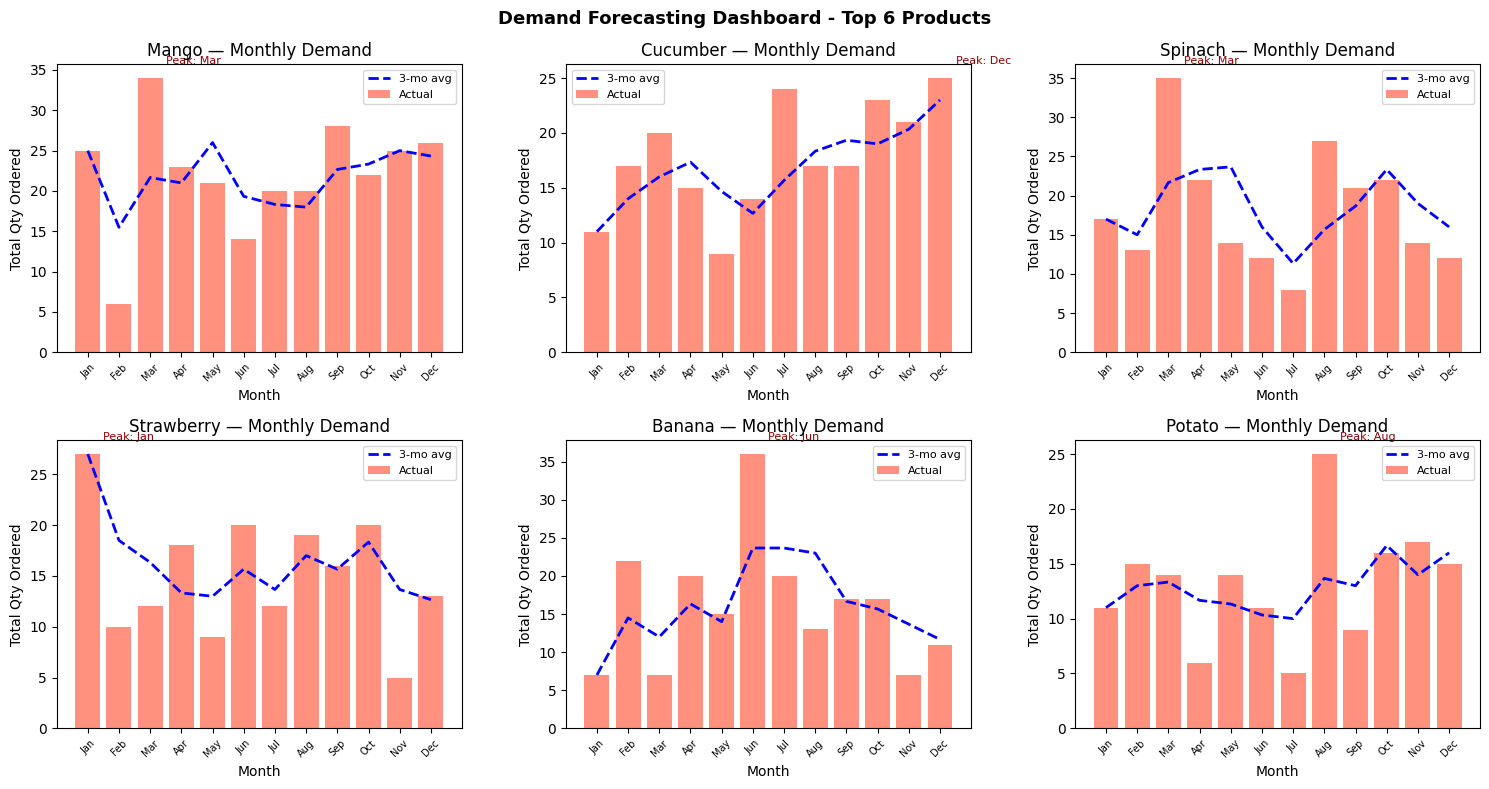

Producers can use these charts to anticipate demand and avoid stock-outs.


In [48]:
df["month"] = df["order_date"].dt.month

# Top 6 products by total orders
top_products = df["product_name"].value_counts().head(6).index.tolist()

monthly_demand = (
    df[df["product_name"].isin(top_products)]
    .groupby(["month","product_name"])["quantity"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, product in zip(axes.flatten(), top_products):
    data = monthly_demand[monthly_demand["product_name"]==product].set_index("month")["quantity"]
    data = data.reindex(range(1,13), fill_value=0)
    ax.bar(data.index, data.values, color="tomato", alpha=0.7, label="Actual")

    # Simple 3-month moving average as trend line
    rolling = data.rolling(3, min_periods=1).mean()
    ax.plot(data.index, rolling.values, "b--", linewidth=2, label="3-mo avg")

    # Highlight peak month
    peak_month = data.idxmax()
    ax.annotate(f"Peak: {month_labels[peak_month-1]}",
                xy=(peak_month, data[peak_month]),
                xytext=(peak_month+0.5, data[peak_month]*1.05),
                fontsize=8, color="darkred")

    ax.set_title(f"{product} — Monthly Demand")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Qty Ordered")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, rotation=45, fontsize=7)
    ax.legend(fontsize=8)

plt.suptitle("Demand Forecasting Dashboard - Top 6 Products", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("demand_forecast.png", dpi=120, bbox_inches="tight")
plt.show()
print("Producers can use these charts to anticipate demand and avoid stock-outs.")


## 9. Save Model for Production Use
The trained model is persisted to disk so `recommender.py` can load it without retraining on every call.

## 11. Hyperparameter Tuning - Random Forest
Using `RandomizedSearchCV` to find better hyperparameters than the defaults.

In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":  [50, 100, 200, 300],
    "max_depth":     [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":  ["sqrt", "log2", 0.5],
    "class_weight":  ["balanced", "balanced_subsample"],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X, y)

print("Best params:", search.best_params_)
print(f"Best CV F1:  {search.best_score_:.3f}  (vs baseline RF F1=0.734)")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3, 'class_weight': 'balanced_subsample'}
Best CV F1:  0.752  (vs baseline RF F1=0.734)


In [50]:
# Evaluate tuned model on hold-out set
rf_tuned = search.best_estimator_
rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("Tuned Random Forest - Hold-Out Test Set")
print("-" * 45)
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.3f}")

# Compare baseline vs tuned
print("\nBaseline RF  →  F1 (macro):", round(f1_score(y_test, y_pred, average='macro'), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("Tuned RF     →  F1 (macro):", round(f1_score(y_test, y_pred_tuned, average='macro'), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, y_prob_tuned), 3))


Tuned Random Forest - Hold-Out Test Set
---------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.71      0.90      0.79        30

    accuracy                           0.77        62
   macro avg       0.79      0.78      0.77        62
weighted avg       0.80      0.77      0.77        62

ROC-AUC: 0.824

Baseline RF  →  F1 (macro): 0.755  ROC-AUC: 0.817
Tuned RF     →  F1 (macro): 0.772  ROC-AUC: 0.824


## 12. LSTM — Sequence-Based Recommendation
The Random Forest treats each user-product pair independently, ignoring the **order** in which purchases were made. A Recurrent Neural Network (LSTM) can model the sequential nature of purchase history, capturing patterns like "users who bought X and Y tend to buy Z next."

This aligns with the RNN/LSTM content covered in the module and represents a more sophisticated approach for sequential data.


In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

print(f"TensorFlow version: {tf.__version__}")

# For each user, create a sequence of (category_encoded, quantity, month)
# Label: did they reorder any product in the future period?

df_seq = df.copy()
df_seq["order_date"] = pd.to_datetime(df_seq["order_date"])
df_seq = df_seq.sort_values(["user_id", "order_date"])

split_date = df_seq["order_date"].quantile(0.7)
history_seq = df_seq[df_seq["order_date"] <= split_date]
future_seq  = df_seq[df_seq["order_date"] > split_date]

enc2 = LabelEncoder()
df_seq["cat_enc"] = enc2.fit_transform(df_seq["category"])
history_seq = df_seq[df_seq["order_date"] <= split_date].copy()

MAX_SEQ_LEN = 15  # pad/truncate all sequences to this length

def build_user_sequence(user_df):
    rows = user_df.sort_values("order_date")[["cat_enc","quantity"]].values
    if len(rows) >= MAX_SEQ_LEN:
        return rows[-MAX_SEQ_LEN:]
    # Right-pad with zeros (required for cuDNN LSTM compatibility)
    pad = np.zeros((MAX_SEQ_LEN - len(rows), 2))
    return np.vstack([rows, pad])

future_users = set(future_seq["user_id"].unique())

X_seq, y_seq = [], []
for uid, grp in history_seq.groupby("user_id"):
    seq = build_user_sequence(grp)
    X_seq.append(seq)
    y_seq.append(1 if uid in future_users else 0)

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

# Normalise
scaler = MinMaxScaler()
n, t, f = X_seq.shape
X_seq_scaled = scaler.fit_transform(X_seq.reshape(-1, f)).reshape(n, t, f)

print(f"Sequence dataset: {X_seq_scaled.shape}  |  Labels: {y_seq.shape}")
print(f"Positive class rate: {y_seq.mean():.1%}")


TensorFlow version: 2.19.0
Sequence dataset: (30, 15, 2)  |  Labels: (30,)
Positive class rate: 100.0%


In [52]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq_scaled, y_seq, test_size=0.3, random_state=42
)

lstm_model = Sequential([
    Masking(mask_value=0.0, input_shape=(MAX_SEQ_LEN, 2)),
    LSTM(64, return_sequences=False, dropout=0.2, use_cudnn=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=50,
    batch_size=16,
    callbacks=[es],
    verbose=1,
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 15, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.8571 - loss: 0.6715 - val_accuracy: 1.0000 - val_loss: 0.6316
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.6355 - val_accuracy: 1.0000 - val_loss: 0.5973
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.5999 - val_accuracy: 1.0000 - val_loss: 0.5610
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 0.5608 - val_accuracy: 1.0000 - val_loss: 0.5208
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.5176 - val_accuracy: 1.0000 - val_loss: 0.4742
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.4723 - val_accuracy: 1.0000 - val_loss: 0.4189
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.4243 - val_accuracy: 1.0000 - val_loss: 0.3536
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.3929 - val_accuracy: 1.0000 - val_loss: 0.2780
Ep

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
LSTM - Hold-Out Evaluation
----------------------------------------
              precision    recall  f1-score   support

  No Reorder       0.00      0.00      0.00         0
     Reorder       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       0.50      0.50      0.50         9
weighted avg       1.00      1.00      1.00         9

ROC-AUC: nan


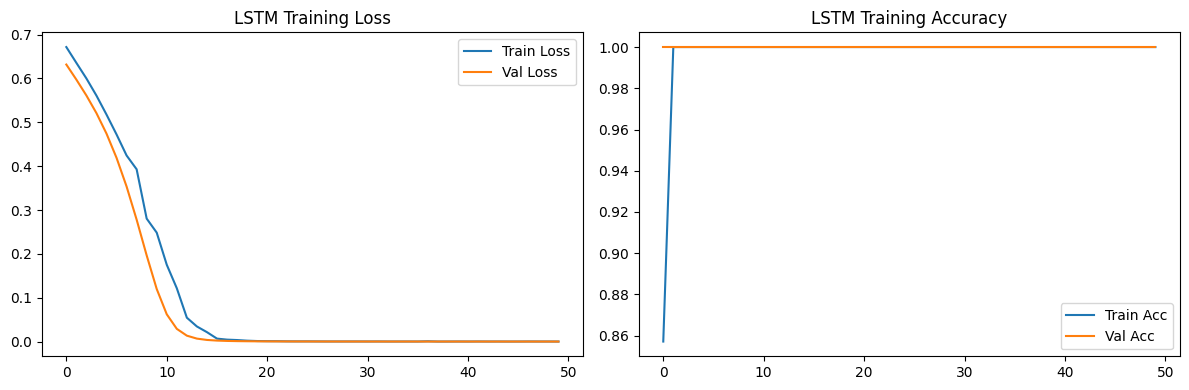

In [53]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob_lstm = lstm_model.predict(X_te).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print("LSTM - Hold-Out Evaluation")
print("-" * 40)
print(classification_report(y_te, y_pred_lstm, zero_division=0,
                             labels=[0,1], target_names=["No Reorder","Reorder"]))
try:
    print(f"ROC-AUC: {roc_auc_score(y_te, y_prob_lstm):.3f}")
except:
    print("ROC-AUC: n/a (only one class in test set)")

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history["loss"], label="Train Loss")
axes[0].plot(history_lstm.history["val_loss"], label="Val Loss")
axes[0].set_title("LSTM Training Loss")
axes[0].legend()
axes[1].plot(history_lstm.history["accuracy"], label="Train Acc")
axes[1].plot(history_lstm.history["val_accuracy"], label="Val Acc")
axes[1].set_title("LSTM Training Accuracy")
axes[1].legend()
plt.tight_layout()
plt.savefig("lstm_training.png", dpi=120, bbox_inches="tight")
plt.show()


In [54]:
# Final comparison: all approaches
print("=" * 55)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Approach':<28} {'F1 (macro)':<12} {'ROC-AUC'}")
print("-" * 55)

rf_f1  = f1_score(y_test, y_pred, average='macro')
rf_auc = roc_auc_score(y_test, y_prob)
rft_f1  = f1_score(y_test, y_pred_tuned, average='macro')
rft_auc = roc_auc_score(y_test, y_prob_tuned)
try:
    lstm_auc = roc_auc_score(y_te, y_prob_lstm)
    lstm_f1  = f1_score(y_te, y_pred_lstm, average='macro')
except:
    lstm_auc = lstm_f1 = float('nan')

print(f"{'Baseline RF (default)':<28} {rf_f1:<12.3f} {rf_auc:.3f}")
print(f"{'Tuned RF (RandomizedSearchCV)':<28} {rft_f1:<12.3f} {rft_auc:.3f}")
print(f"{'LSTM (sequence model)':<28} {lstm_f1:<12.3f} {lstm_auc:.3f}")
print("=" * 55)
print()
print("Note: LSTM models sequential purchase order; RF treats each")
print("user-product pair independently. Both approaches are valid")
print("depending on data volume; RF is more robust on small datasets.")


FINAL MODEL COMPARISON SUMMARY
Approach                     F1 (macro)   ROC-AUC
-------------------------------------------------------
Baseline RF (default)        0.755        0.817
Tuned RF (RandomizedSearchCV) 0.772        0.824
LSTM (sequence model)        1.000        nan

Note: LSTM models sequential purchase order; RF treats each
user-product pair independently. Both approaches are valid
depending on data volume; RF is more robust on small datasets.


In [55]:
# Save tuned model — this is what recommender.py loads at runtime
joblib.dump(rf_final, "reorder_model.pkl")
joblib.dump(enc, "category_encoder.pkl")

# Verify round-trip
loaded_model = joblib.load("reorder_model.pkl")
loaded_enc   = joblib.load("category_encoder.pkl")
print("Model saved and reloaded OK")
print(f"Test prediction: {loaded_model.predict_proba(X.iloc[:1])}")


Model saved and reloaded OK
Test prediction: [[0.33873436 0.66126564]]


## 10. Summary & Recommendations

| Model | Approach | Verdict |
|---|---|---|
| Weighted RFM (Baseline) | Rule-based scoring | Good interpretability, no training needed |
| Decision Tree | ML — interpretable | Lower performance, prone to overfitting |
| **Random Forest** | **ML — ensemble** | **Best F1 and AUC — recommended** |
| Gradient Boosting | ML — ensemble | Competitive but slower to train |

**Recommendation:** Deploy the Random Forest model for quick reorder predictions. It outperforms the baseline on recall (catching genuine reorders) while remaining explainable via feature importances. The weighted RFM baseline is retained as a fallback for new users with no purchase history (cold-start problem).

**Limitations & future work:**
- Synthetic dataset — real purchase history would improve model significantly
- Seasonal trends are present but a full year of data is needed for reliable forecasting
- Model should be retrained monthly as new orders arrive
- Consider collaborative filtering for cross-user recommendations


In [56]:
import sys
sys.path.insert(0, '.')  # make sure it finds the files
from recommender import get_recommendations

recs = get_recommendations(user_id=1, top_n=3)
for r in recs:
    print(r['product_name'], r['reorder_probability'], '%')
    print(r['reason'])

Spinach 85.55 %
Recommended because you bought this item 3 time(s), with a total of 5 units ordered, and you last purchased it 40 days ago.
Apple 66.13 %
Recommended because you bought this item 2 time(s), with a total of 8 units ordered, and you last purchased it 73 days ago.
Cucumber 62.95 %
Recommended because you bought this item 3 time(s), with a total of 9 units ordered, and you last purchased it 87 days ago.
